Demo — Mecanismos de Attention aplicados a Fintech
¶
Aula 7 | AI Engineering | MBA


Este notebook acompanha os Módulos 1 e 2 da aula:




Self-Attention "na mão" com NumPy


Versão profissional em PyTorch


FinBERT em manchetes financeiras


Discussão de integração em pipeline Fintech

1. Setup
¶

In [1]:
# !pip install transformers torch pandas matplotlib seaborn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
sns.set_style("whitegrid")


2. Self-Attention na mão (NumPy)
¶
Vamos calcular:
$$\text{Attention}(Q,K,V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right)V$$


para a mini-sequência 
['receita','cresceu','apesar','inadimplência']
 — trecho de relatório financeiro.

In [2]:
tokens = ["receita", "cresceu", "apesar", "inadimplencia"]
d_model = 8
d_k     = 8

# Embeddings simulados (em producao viriam de uma camada de embedding treinada)
X = np.random.randn(len(tokens), d_model)
print("Embeddings X shape:", X.shape)

# Matrizes de projecao W_Q, W_K, W_V (aprendidas durante o treino)
W_Q = np.random.randn(d_model, d_k) * 0.1
W_K = np.random.randn(d_model, d_k) * 0.1
W_V = np.random.randn(d_model, d_k) * 0.1

Q = X @ W_Q
K = X @ W_K
V = X @ W_V
print("Q:", Q.shape, "| K:", K.shape, "| V:", V.shape)


Embeddings X shape: (4, 8)
Q: (4, 8) | K: (4, 8) | V: (4, 8)


In [3]:
def softmax(x, axis=-1):
    x = x - x.max(axis=axis, keepdims=True)
    e = np.exp(x)
    return e / e.sum(axis=axis, keepdims=True)

# Passo 1: similaridade Q . K^T
scores = Q @ K.T
# Passo 2: escala 1/sqrt(d_k)
scores_scaled = scores / np.sqrt(d_k)
# Passo 3: softmax para virar distribuicao de pesos
attn_weights = softmax(scores_scaled, axis=-1)
# Passo 4: ponderar os Values
output = attn_weights @ V

print("Matriz de pesos de atencao (cada linha soma 1):")
print(np.round(attn_weights, 3))


Matriz de pesos de atencao (cada linha soma 1):
[[0.235 0.264 0.246 0.255]
 [0.257 0.235 0.244 0.265]
 [0.268 0.243 0.254 0.235]
 [0.242 0.259 0.248 0.251]]


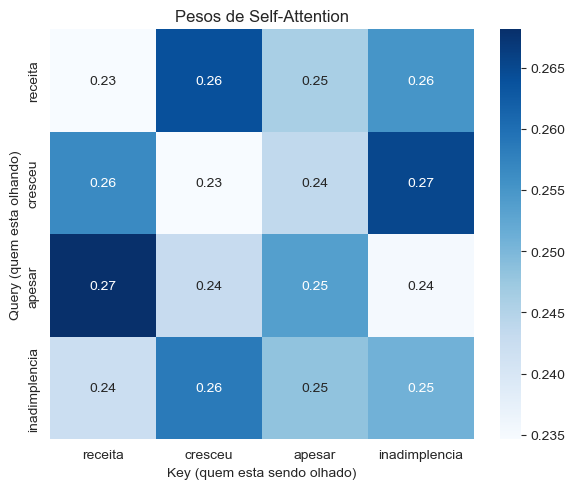

In [4]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(attn_weights, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=tokens, yticklabels=tokens, ax=ax, cbar=True)
ax.set_title("Pesos de Self-Attention")
ax.set_xlabel("Key (quem esta sendo olhado)")
ax.set_ylabel("Query (quem esta olhando)")
plt.tight_layout()
plt.show()


Interpretação:
 Cada linha representa um token consultando os outros. Em um modelo treinado, 'inadimplência' tenderia a focar em 'apesar' e 'receita', capturando a relação contrastiva.

3. Self-Attention em PyTorch
¶

In [5]:
class SelfAttention(nn.Module):
    def __init__(self, d_model, d_k):
        super().__init__()
        self.d_k = d_k
        self.W_q = nn.Linear(d_model, d_k, bias=False)
        self.W_k = nn.Linear(d_model, d_k, bias=False)
        self.W_v = nn.Linear(d_model, d_k, bias=False)

    def forward(self, x):
        Q = self.W_q(x)
        K = self.W_k(x)
        V = self.W_v(x)
        scores = Q @ K.transpose(-2, -1) / (self.d_k ** 0.5)
        attn = F.softmax(scores, dim=-1)
        out = attn @ V
        return out, attn

attn_layer = SelfAttention(d_model=8, d_k=8)
x = torch.randn(1, 4, 8)
out, attn = attn_layer(x)
print("Output shape:", out.shape)
print("Attention shape:", attn.shape)
print(torch.round(attn[0], decimals=3))


Output shape: torch.Size([1, 4, 8])
Attention shape: torch.Size([1, 4, 4])
tensor([[0.4080, 0.1450, 0.2890, 0.1570],
        [0.2880, 0.2240, 0.2980, 0.1890],
        [0.1290, 0.2820, 0.3220, 0.2670],
        [0.2830, 0.2390, 0.2410, 0.2370]], grad_fn=<RoundBackward1>)


4. FinBERT — Sentimento de manchetes financeiras
¶
Carregamos o dataset sintético e aplicamos o FinBERT (Araci, 2019), BERT fine-tunado em corpus financeiro.

In [6]:
df = pd.read_csv("manchetes_finbert.csv", parse_dates=["date"])
print(f"Dataset: {len(df)} manchetes | {df['ticker'].nunique()} tickers")
df.head()


Dataset: 200 manchetes | 10 tickers


,date,ticker,headline,source
0,2025-11-26,PETR4,"Petrobras reports surprise loss in Q3, shares ...",CNBC
1,2025-11-27,BBDC4,Bradesco declares record quarterly dividend,Financial Times
2,2025-11-28,ITUB4,Itau Unibanco downgraded to Sell on rising deb...,Financial Times
3,2025-11-28,BBDC4,Bradesco announces $​17.9B stock buyback program,CNBC
4,2025-12-03,TSLA,Analysts upgrade Tesla to Buy citing strong ca...,Reuters


In [7]:
from transformers import pipeline

finbert = pipeline(
    task="sentiment-analysis",
    model="ProsusAI/finbert",
    tokenizer="ProsusAI/finbert",
    device=0 if torch.cuda.is_available() else -1,
)

results = finbert(df["headline"].tolist(), truncation=True, batch_size=16)
df["sentiment"] = [r["label"] for r in results]
df["score"]     = [r["score"] for r in results]
df.head()


/Users/dhenyfernandes/anaconda3/lib/python3.10/site-packages/huggingface_hub/file_download.py:1150: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


,date,ticker,headline,source,sentiment,score
0,2025-11-26,PETR4,"Petrobras reports surprise loss in Q3, shares ...",CNBC,negative,0.943539
1,2025-11-27,BBDC4,Bradesco declares record quarterly dividend,Financial Times,positive,0.462841
2,2025-11-28,ITUB4,Itau Unibanco downgraded to Sell on rising deb...,Financial Times,negative,0.961676
3,2025-11-28,BBDC4,Bradesco announces $​17.9B stock buyback program,CNBC,neutral,0.880624
4,2025-12-03,TSLA,Analysts upgrade Tesla to Buy citing strong ca...,Reuters,positive,0.944536


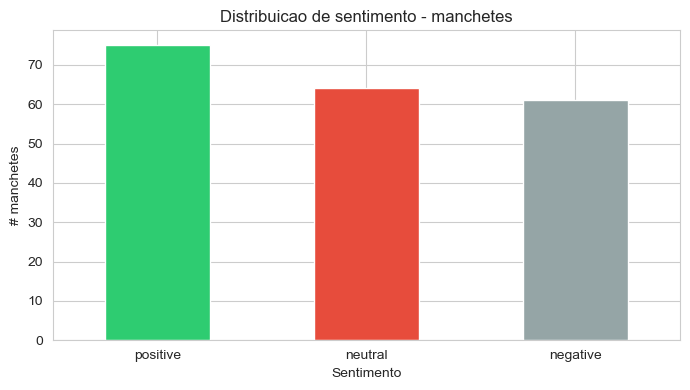

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
df["sentiment"].value_counts().plot(kind="bar",
    color=["#2ecc71","#e74c3c","#95a5a6"], ax=ax)
ax.set_title("Distribuicao de sentimento - manchetes")
ax.set_xlabel("Sentimento"); ax.set_ylabel("# manchetes")
plt.xticks(rotation=0); plt.tight_layout(); plt.show()


/var/folders/8r/76rtgv650dq8578qqnhrpvym0000gn/T/ipykernel_89905/3186377858.py:2: FutureWarning: Not prepending group keys to the result index of transform-like apply. In the future, the group keys will be included in the index, regardless of whether the applied function returns a like-indexed object.
To preserve the previous behavior, use

	>>> .groupby(..., group_keys=False)

To adopt the future behavior and silence this warning, use 

	>>> .groupby(..., group_keys=True)
  .groupby(level=0).apply(lambda s: s / s.sum())


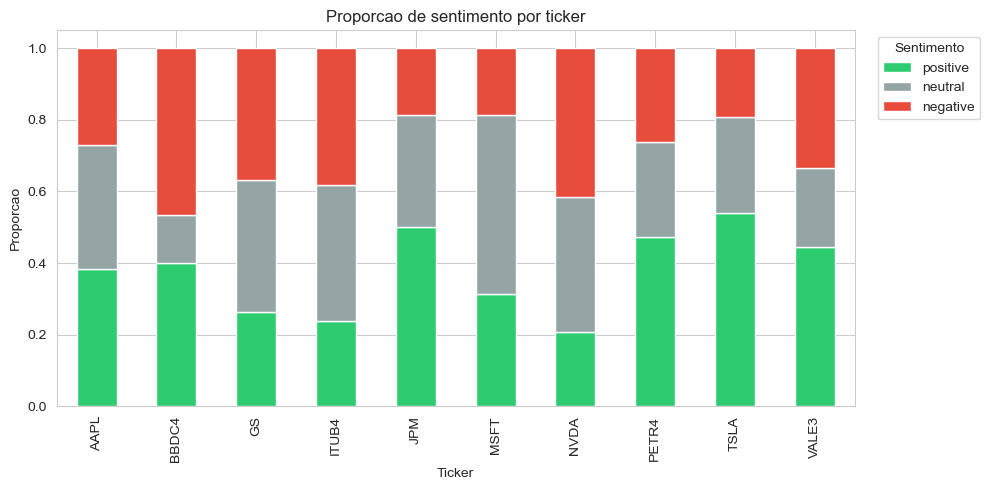

In [9]:
prop = (df.groupby(["ticker","sentiment"]).size()
          .groupby(level=0).apply(lambda s: s / s.sum())
          .unstack(fill_value=0))
for col in ["positive","neutral","negative"]:
    if col not in prop.columns:
        prop[col] = 0
prop = prop[["positive","neutral","negative"]]

fig, ax = plt.subplots(figsize=(10, 5))
prop.plot(kind="bar", stacked=True, ax=ax,
          color=["#2ecc71","#95a5a6","#e74c3c"])
ax.set_title("Proporcao de sentimento por ticker")
ax.set_ylabel("Proporcao"); ax.set_xlabel("Ticker")
ax.legend(title="Sentimento", bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout(); plt.show()


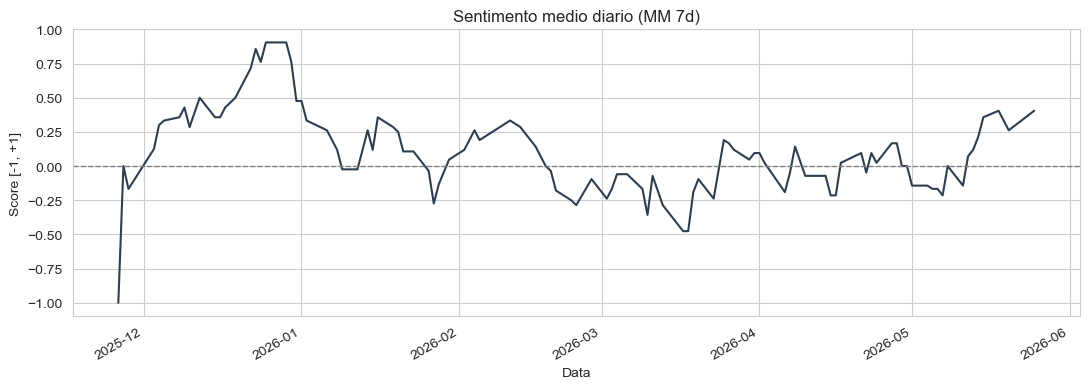

In [10]:
sent_map = {"positive": 1, "neutral": 0, "negative": -1}
df["sent_num"] = df["sentiment"].map(sent_map)
daily = df.groupby("date")["sent_num"].mean().rolling(7, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(11, 4))
daily.plot(ax=ax, color="#2c3e50")
ax.axhline(0, color="gray", linestyle="--", linewidth=1)
ax.set_title("Sentimento medio diario (MM 7d)")
ax.set_ylabel("Score [-1, +1]"); ax.set_xlabel("Data")
plt.tight_layout(); plt.show()


6. Exercícios propostos


Multi-Head Attention
: estenda a classe 
SelfAttention
 para 4 cabeças e visualize.


In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class MultiHeadAttention(nn.Module):

    def __init__(self, d_model=32, num_heads=4):
        super().__init__()

        assert d_model % num_heads == 0

        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads

        self.Wq = nn.Linear(d_model, d_model)
        self.Wk = nn.Linear(d_model, d_model)
        self.Wv = nn.Linear(d_model, d_model)

        self.out = nn.Linear(d_model, d_model)

    def forward(self, x):

        batch_size, seq_len, _ = x.shape

        Q = self.Wq(x)
        K = self.Wk(x)
        V = self.Wv(x)

        Q = Q.view(batch_size, seq_len,
                   self.num_heads, self.head_dim).transpose(1,2)

        K = K.view(batch_size, seq_len,
                   self.num_heads, self.head_dim).transpose(1,2)

        V = V.view(batch_size, seq_len,
                   self.num_heads, self.head_dim).transpose(1,2)

        scores = torch.matmul(
            Q,
            K.transpose(-2,-1)
        ) / (self.head_dim ** 0.5)

        weights = F.softmax(scores, dim=-1)

        attention = torch.matmul(weights, V)

        attention = attention.transpose(1,2).contiguous()

        attention = attention.view(
            batch_size,
            seq_len,
            self.d_model
        )

        return self.out(attention), weights


x = torch.randn(1, 6, 32)

mha = MultiHeadAttention()

output, weights = mha(x)

print(output.shape)
print(weights.shape)

torch.Size([1, 6, 32])
torch.Size([1, 4, 6, 6])
